# Unità 3 — E91 ideale

In questo notebook simuliamo una versione didattica del protocollo E91 nel caso ideale. A differenza di BB84, il protocollo E91 si basa su coppie entangled condivise tra Alice e Bob.

## Setup e import

Prepariamo il percorso del progetto in modo da poter importare le funzioni dalla cartella `src`, anche quando il notebook viene eseguito dalla cartella `notebooks`.

In [17]:
from pathlib import Path
import sys

current_path = Path.cwd()

if (current_path / "src" / "e91.py").exists():
    project_root = current_path
elif (current_path.parent / "src" / "e91.py").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError("Non trovo la cartella src del progetto.")

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

In [18]:
import pandas as pd
from qiskit import QuantumCircuit

from e91 import (
    random_bases,
    prepare_bell_phi_plus,
    measure_e91_qubit,
    run_e91_round,
    run_e91_protocol,
    sift_keys,
    compute_qber,
    run_chsh_experiment,
)

## Differenza concettuale tra BB84 ed E91

In BB84 Alice prepara direttamente gli stati quantistici da inviare a Bob. In E91, invece, Alice e Bob ricevono due qubit entangled. La chiave nasce dalle correlazioni tra i risultati di misura.

## Preparazione dello stato di Bell

Usiamo lo stato |Phi+> = (|00> + |11>) / sqrt(2). Questo stato è entangled: non descrive due qubit indipendenti, ma un sistema bipartito con forti correlazioni.

In [19]:
circuit = QuantumCircuit(2, 2)
prepare_bell_phi_plus(circuit)

print(circuit.draw())

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
c: 2/══════════
               


## Misura in base Z e in base X

Come in BB84, la misura in base Z è diretta. La misura in base X viene simulata applicando un gate H prima della misura.

In [20]:
circuit = QuantumCircuit(2, 2)
prepare_bell_phi_plus(circuit)
measure_e91_qubit(circuit, basis="X", qubit=0, cbit=0)
measure_e91_qubit(circuit, basis="X", qubit=1, cbit=1)

print(circuit.draw())

     ┌───┐     ┌───┐┌─┐   
q_0: ┤ H ├──■──┤ H ├┤M├───
     └───┘┌─┴─┐├───┤└╥┘┌─┐
q_1: ─────┤ X ├┤ H ├─╫─┤M├
          └───┘└───┘ ║ └╥┘
c: 2/════════════════╩══╩═
                     0  1 


## Singolo round E91

In un round E91 ideale, Alice misura il proprio qubit e Bob misura il proprio qubit. Se scelgono la stessa base, nel caso ideale i risultati sono correlati.

In [21]:
round_z = run_e91_round(alice_basis="Z", bob_basis="Z")
print("Round in base Z:", round_z)

round_x = run_e91_round(alice_basis="X", bob_basis="X")
print("Round in base X:", round_x)

Round in base Z: {'alice_basis': 'Z', 'bob_basis': 'Z', 'alice_bit': 1, 'bob_bit': 1}
Round in base X: {'alice_basis': 'X', 'bob_basis': 'X', 'alice_bit': 1, 'bob_bit': 1}


## Protocollo multi-round

Ora ripetiamo il protocollo più volte. Per ogni round salviamo la base scelta da Alice, la base scelta da Bob, i bit ottenuti e l'informazione `keep`, cioè se il round viene mantenuto dopo il confronto delle basi.

In [22]:
results = run_e91_protocol(n_rounds=30, seed=123)

for i in range(5):
    print(results[i])

{'round': 1, 'alice_basis': 'Z', 'bob_basis': 'X', 'alice_bit': 1, 'bob_bit': 0, 'keep': False}
{'round': 2, 'alice_basis': 'X', 'bob_basis': 'X', 'alice_bit': 0, 'bob_bit': 0, 'keep': True}
{'round': 3, 'alice_basis': 'X', 'bob_basis': 'X', 'alice_bit': 1, 'bob_bit': 1, 'keep': True}
{'round': 4, 'alice_basis': 'Z', 'bob_basis': 'X', 'alice_bit': 0, 'bob_bit': 1, 'keep': False}
{'round': 5, 'alice_basis': 'X', 'bob_basis': 'X', 'alice_bit': 1, 'bob_bit': 1, 'keep': True}


## Sifting

Come in BB84, manteniamo solo i round in cui Alice e Bob hanno scelto la stessa base.

In [23]:
alice_key, bob_key = sift_keys(results)

print("Chiave di Alice:", alice_key)
print("Chiave di Bob:", bob_key)
print("Lunghezza della chiave sifted:", len(alice_key))

Chiave di Alice: [0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1]
Chiave di Bob: [0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1]
Lunghezza della chiave sifted: 13


## Calcolo del QBER

Nel caso ideale, se Alice e Bob misurano coppie entangled nella stessa base, i bit della chiave sifted coincidono. Il QBER deve quindi essere nullo.

In [24]:
qber = compute_qber(alice_key, bob_key)

print("QBER:", qber)

if qber == 0:
    print("Nel caso E91 ideale il QBER è nullo.")
else:
    print("È stato ottenuto un QBER non nullo: controllare la simulazione.")

QBER: 0.0
Nel caso E91 ideale il QBER è nullo.


## Rappresentazione tabellare

La simulazione restituisce una lista di dizionari. Per visualizzare meglio i risultati, possiamo convertirla in una tabella pandas. Questa è solo una fase di rappresentazione, separata dalla logica del protocollo.

In [25]:
df = pd.DataFrame(results)
df.head(10)

,round,alice_basis,bob_basis,alice_bit,bob_bit,keep
0,1,Z,X,1,0,False
1,2,X,X,0,0,True
2,3,X,X,1,1,True
3,4,Z,X,0,1,False
4,5,X,X,1,1,True
5,6,Z,X,0,0,False
6,7,Z,Z,0,0,True
7,8,Z,X,0,1,False
8,9,Z,X,1,0,False
9,10,Z,X,1,1,False


## Commento finale

Nel caso ideale, E91 permette ad Alice e Bob di ottenere bit correlati misurando qubit entangled. Quando le basi coincidono, i risultati possono essere usati per costruire una chiave condivisa e il QBER risulta nullo. Nei passaggi successivi questa simulazione potrà essere estesa introducendo il test CHSH o confrontando E91 con BB84.

## Salvataggio e grafico dei risultati

La simulazione E91 ideale ha prodotto una lista di round e una tabella. In questa sezione salviamo la tabella e rappresentiamo quanti round vengono mantenuti o scartati dopo il confronto delle basi.

In [26]:
from pathlib import Path

tables_dir = project_root / "results" / "tables"
figures_dir = project_root / "results" / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Cartelle dei risultati pronte.")

Cartelle dei risultati pronte.


In [27]:
table_path = tables_dir / "e91_ideal_results.csv"
df.to_csv(table_path, index=False)

print(f"Tabella salvata in: {table_path}")

Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_ideal_results.csv


In [28]:
kept_rounds = 0
discarded_rounds = 0

for i in range(len(results)):
    if results[i]["keep"] == True:
        kept_rounds += 1
    else:
        discarded_rounds += 1

print("Round mantenuti:", kept_rounds)
print("Round scartati:", discarded_rounds)

Round mantenuti: 13
Round scartati: 17


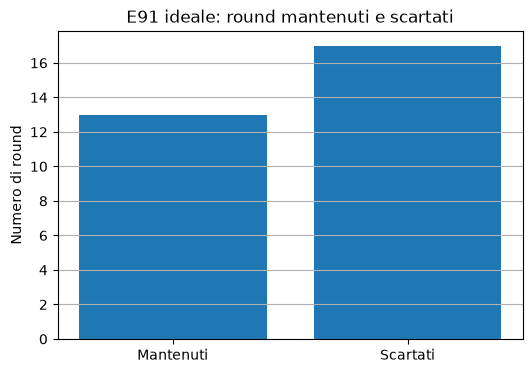

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_ideal_keep_discard.png


In [29]:
import matplotlib.pyplot as plt

labels = ["Mantenuti", "Scartati"]
values = [kept_rounds, discarded_rounds]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.ylabel("Numero di round")
plt.title("E91 ideale: round mantenuti e scartati")
plt.grid(axis="y")

figure_path = figures_dir / "e91_ideal_keep_discard.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico salvato in: {figure_path}")

In E91 ideale Alice e Bob mantengono solo i round in cui scelgono la stessa base. Sui round mantenuti, nel caso ideale, i bit risultano correlati: per questo il QBER ottenuto nel notebook è nullo. Il grafico mostra solo il processo di sifting, mentre l'analisi più avanzata delle correlazioni sarà affrontata con CHSH.

## Estensione: correlazioni quantistiche e test CHSH

Il protocollo E91 è basato su coppie entangled. L'entanglement produce correlazioni tra i risultati di Alice e Bob, e il test CHSH permette di confrontare queste correlazioni con il limite previsto da teorie classiche locali.

Per modelli classici locali vale |S| <= 2. Per uno stato quantistico entangled ideale si può ottenere |S| vicino a 2*sqrt(2).

Usiamo la combinazione:

S = E(a,b) + E(a,b') + E(a',b) - E(a',b')

In [30]:
shots = 5000

chsh_result = run_chsh_experiment(
    shots=shots,
    seed=123,
)

print("Risultati del test CHSH:")
print("E(a, b):", chsh_result["E_ab"])
print("E(a, b'):", chsh_result["E_ab_prime"])
print("E(a', b):", chsh_result["E_a_prime_b"])
print("E(a', b'):", chsh_result["E_a_prime_b_prime"])
print("S:", chsh_result["S"])
print("|S|:", abs(chsh_result["S"]))

Risultati del test CHSH:
E(a, b): 0.71
E(a, b'): 0.696
E(a', b): 0.7188
E(a', b'): -0.6928
S: 2.8176
|S|: 2.8176


In [31]:
if abs(chsh_result["S"]) > 2:
    print("Il valore ottenuto viola il limite classico |S| <= 2.")
else:
    print("Il valore ottenuto non viola il limite classico: controllare il numero di shot o la simulazione.")

print("Valore teorico massimo quantistico: circa 2.828.")

Il valore ottenuto viola il limite classico |S| <= 2.
Valore teorico massimo quantistico: circa 2.828.


Il valore ottenuto può non essere esattamente 2.828 perché la simulazione usa un numero finito di shot. La violazione di CHSH mostra che le correlazioni dello stato entangled non sono descrivibili con un modello classico locale. Questa parte non serve direttamente a calcolare il QBER, ma rafforza l'interpretazione fisica del protocollo E91. Nella relazione finale si potrà presentare CHSH come estensione teorica del protocollo E91.